<a href="https://colab.research.google.com/github/HVDEER/google_colab/blob/main/HourlyEnergyConsumptionbyrobmulla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()


Saving HourlyEnergyConsumptionRobMulla.zip to HourlyEnergyConsumptionRobMulla.zip


In [2]:
!unzip -q HourlyEnergyConsumptionRobMulla.zip


In [3]:
!ls


AEP_hourly.csv	   EKPC_hourly.csv			pjm_hourly_est.csv
COMED_hourly.csv   est_hourly.paruqet			PJM_Load_hourly.csv
DAYTON_hourly.csv  FE_hourly.csv			PJMW_hourly.csv
DEOK_hourly.csv    HourlyEnergyConsumptionRobMulla.zip	sample_data
DOM_hourly.csv	   NI_hourly.csv
DUQ_hourly.csv	   PJME_hourly.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [5]:
df = pd.read_csv("PJME_hourly.csv")

In [6]:
df.head()


,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [7]:
df.describe()


,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


In [8]:
df.columns


Index(['Datetime', 'PJME_MW'], dtype='object')

In [9]:
df = pd.read_csv(
    "PJME_hourly.csv",
    parse_dates=['Datetime'],
    index_col='Datetime'
)


In [10]:
df.index
# shows the datetime index


DatetimeIndex(['2002-12-31 01:00:00', '2002-12-31 02:00:00',
               '2002-12-31 03:00:00', '2002-12-31 04:00:00',
               '2002-12-31 05:00:00', '2002-12-31 06:00:00',
               '2002-12-31 07:00:00', '2002-12-31 08:00:00',
               '2002-12-31 09:00:00', '2002-12-31 10:00:00',
               ...
               '2018-01-01 15:00:00', '2018-01-01 16:00:00',
               '2018-01-01 17:00:00', '2018-01-01 18:00:00',
               '2018-01-01 19:00:00', '2018-01-01 20:00:00',
               '2018-01-01 21:00:00', '2018-01-01 22:00:00',
               '2018-01-01 23:00:00', '2018-01-02 00:00:00'],
              dtype='datetime64[ns]', name='Datetime', length=145366, freq=None)

<Axes: xlabel='Datetime'>

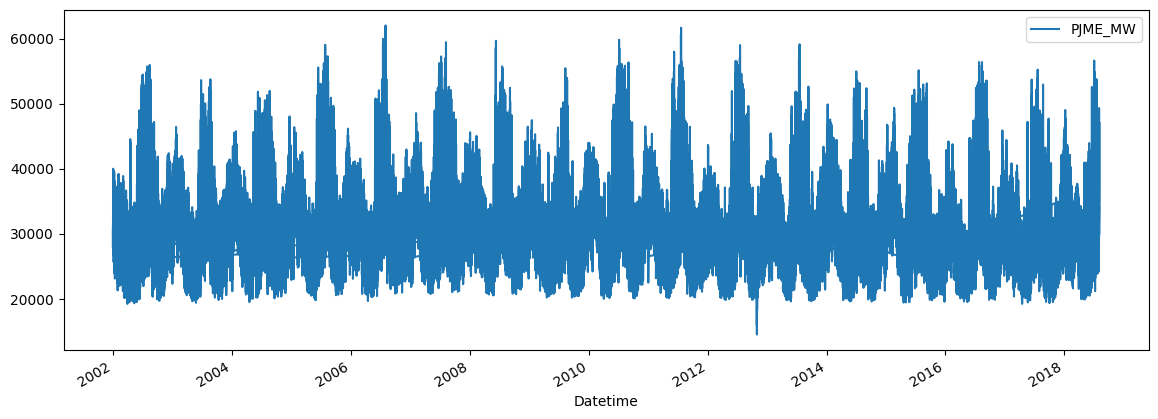

In [11]:
df.plot(figsize=(14,5))
# visualize energy consumption over time


*Note the lowest drop in 2013? Cause?

*Figure 1:*
plotted electricity usage over time.

Y-axis → electricity consumption (PJME_MW)

X-axis → time order of observations.

In [12]:
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month
df['year'] = df.index.year

In [13]:
df.isna().sum()
df = df.drop_duplicates()


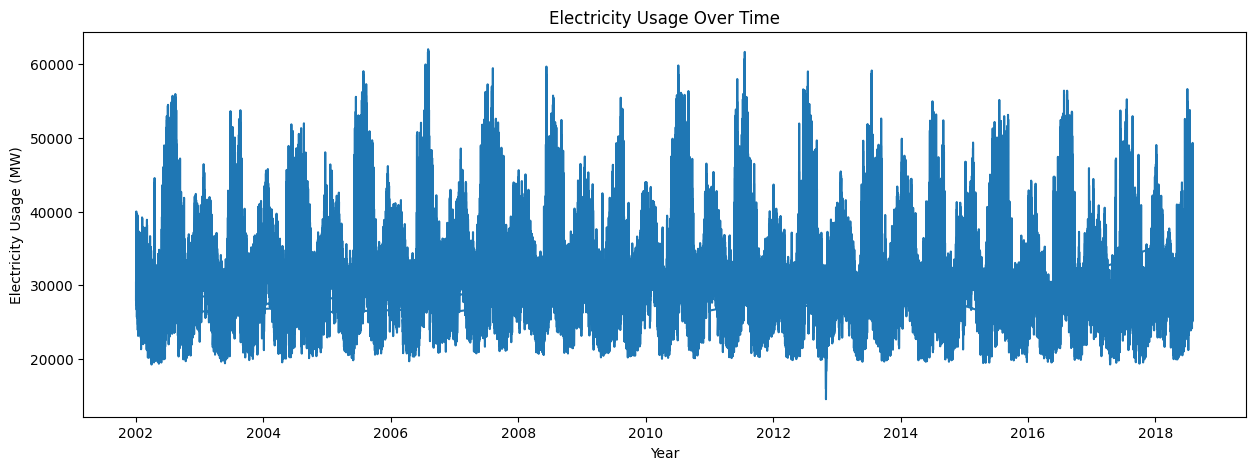

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df.index, df['PJME_MW'])
plt.title('Electricity Usage Over Time')
plt.xlabel('Year')
plt.ylabel('Electricity Usage (MW)')
plt.show()


Chart looks normal, electricity usage is seasonal, appears usage is lower to normal beggining of the year then increases during summer drastically.

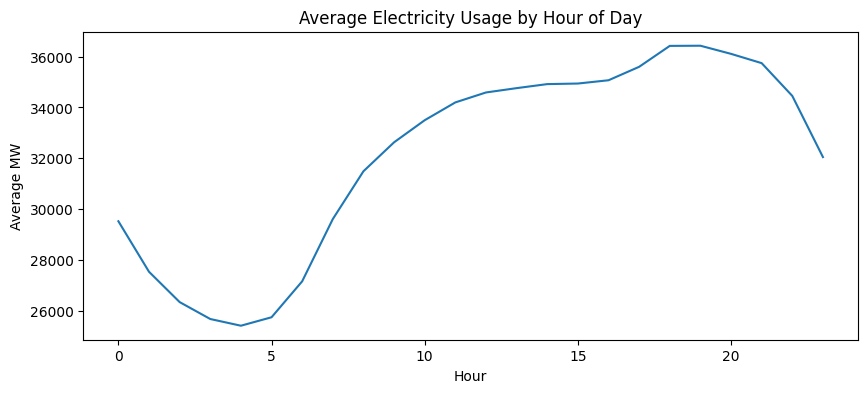

In [15]:
hourly_avg = df.groupby(df.index.hour)['PJME_MW'].mean()

plt.figure(figsize=(10,4))
hourly_avg.plot()
plt.title('Average Electricity Usage by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average MW')
plt.show()


**Analysis:** at midnight usage of electricity is av. and decreases drastically until 4Am, by 5 it begins to rise and gradualy continues to do so until 10AM where it starts being mor constant until 3PM. There is a spike from 4-6PM then downfall of usage onwards till once more 12AM.
**Deduction:** People start their days early and cuse a lot of electricity from 7 AM to 7PM. Morning to early evening hours show consistently higher usage.


***Corrected:***

**Analysis:** The average electricity usage is lowest during the late night and early morning hours, with a noticeable decline from midnight until around 4 AM. Starting from early morning, usage begins to rise steadily, reaching a relatively stable level between mid-morning and early afternoon. A pronounced peak is observed during the late afternoon to early evening hours (approximately 4–6 PM), after which electricity usage gradually declines toward midnight.

**Deduction:** This pattern suggests that electricity demand increases during daytime hours, likely reflecting human activity such as work, household tasks, and commercial operations, with peak demand occurring in the early evening when people return home.

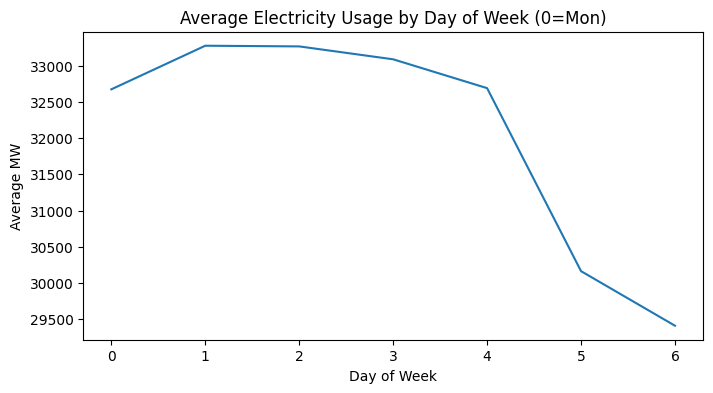

In [16]:
dow_avg = df.groupby(df.index.dayofweek)['PJME_MW'].mean()

plt.figure(figsize=(8,4))
dow_avg.plot()
plt.title('Average Electricity Usage by Day of Week (0=Mon)')
plt.xlabel('Day of Week')
plt.ylabel('Average MW')
plt.show()


Data shows that average electricity usage is highest on Tuesday and lowest during weekedn suggesting people go out for the weekend. Friday the usage also decreases drastically compared to Monday, Tuesday, Wednesday, and Thursday.

***Corrected***

**Analysis:**
The data shows that average electricity usage is highest on Tuesday and generally higher during weekdays compared to weekends. Electricity demand is lowest during the weekend, with Friday also showing a noticeable decrease compared to Monday through Thursday.

**Deduction:**
This pattern suggests that electricity demand is strongly influenced by weekday activities, likely driven by business, industrial, and routine household usage, while reduced activity during weekends corresponds to lower overall demand.

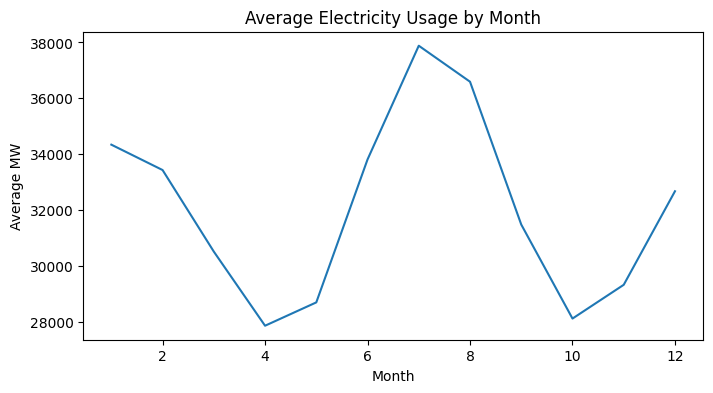

In [17]:
month_avg = df.groupby(df.index.month)['PJME_MW'].mean()

plt.figure(figsize=(8,4))
month_avg.plot()
plt.title('Average Electricity Usage by Month')
plt.xlabel('Month')
plt.ylabel('Average MW')
plt.show()


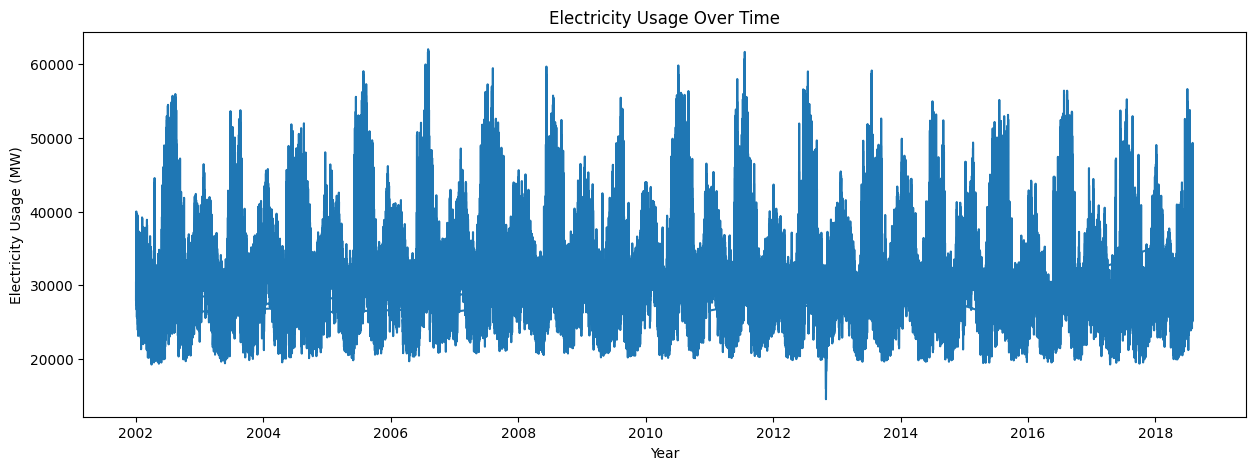

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df.index, df['PJME_MW'])
plt.title('Electricity Usage Over Time')
plt.xlabel('Year')
plt.ylabel('Electricity Usage (MW)')
plt.show()


Now we turn time into numbers that a model can learn from.

In [19]:
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month
df['year'] = df.index.year


In [20]:
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)


In [21]:
df.head()


,PJME_MW,hour,dayofweek,month,year,is_weekend
Datetime,,,,,,
2002-12-31 01:00:00,26498.0,1,1,12,2002,0
2002-12-31 02:00:00,25147.0,2,1,12,2002,0
2002-12-31 03:00:00,24574.0,3,1,12,2002,0
2002-12-31 04:00:00,24393.0,4,1,12,2002,0
2002-12-31 05:00:00,24860.0,5,1,12,2002,0


In [22]:
print(df.index.min())
print(df.index.max())


2002-01-01 01:00:00
2018-08-03 00:00:00


In [23]:
train = df[df.index < '2018-01-01']
test  = df[df.index >= '2018-01-01']

print("Train rows:", len(train))
print("Test rows:", len(test))

#“Use all data before 2018 to learn, and use 2018 data to test.”

Train rows: 140192
Test rows: 5135


In [24]:
features = ['hour', 'dayofweek', 'month', 'year', 'is_weekend']
target = 'PJME_MW'

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]


In [25]:
baseline_value = y_train.mean()
baseline_value

#“On average, electricity usage in the past was X megawatts.”

np.float64(32091.822579034466)

In [26]:
baseline_predictions = [baseline_value] * len(y_test)
#“For every hour in 2018, guess the same average value.”

My baseline: Predict the same average electricity usage for every hour in 2018

In [27]:
from sklearn.metrics import mean_absolute_error

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_mae

#“On average, how many megawatts off is this dumb guess?”

4963.662948480781

Mean Absolute Error (MAE)?

In [28]:
from sklearn.ensemble import RandomForestRegressor
#Model that learns patterns by combining many decision trees.

In [29]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


In [30]:
rf.fit(X_train, y_train)
#Learn the relationship between time features and electricity usage
#using past data.

RandomForestRegressor(n_jobs=-1, random_state=42)

In [31]:
rf_preds = rf.predict(X_test)
# Use the learned patterns to predict electricity usage in 2018.

In [32]:
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_mae


2981.10122022132

rf_mae must be LOWER than baseline_mae

Different charts below to visualize data:

**Note:** “Hourly electricity demand exhibits high short-term volatility, making long-horizon hourly visualizations difficult to interpret. Aggregated and distribution-based plots provide clearer insight into model performance.”

In [36]:
comparison = test.copy()
comparison['prediction'] = rf_preds


<Axes: title={'center': 'Daily Average: Actual vs Predicted Electricity Usage'}, xlabel='Datetime'>

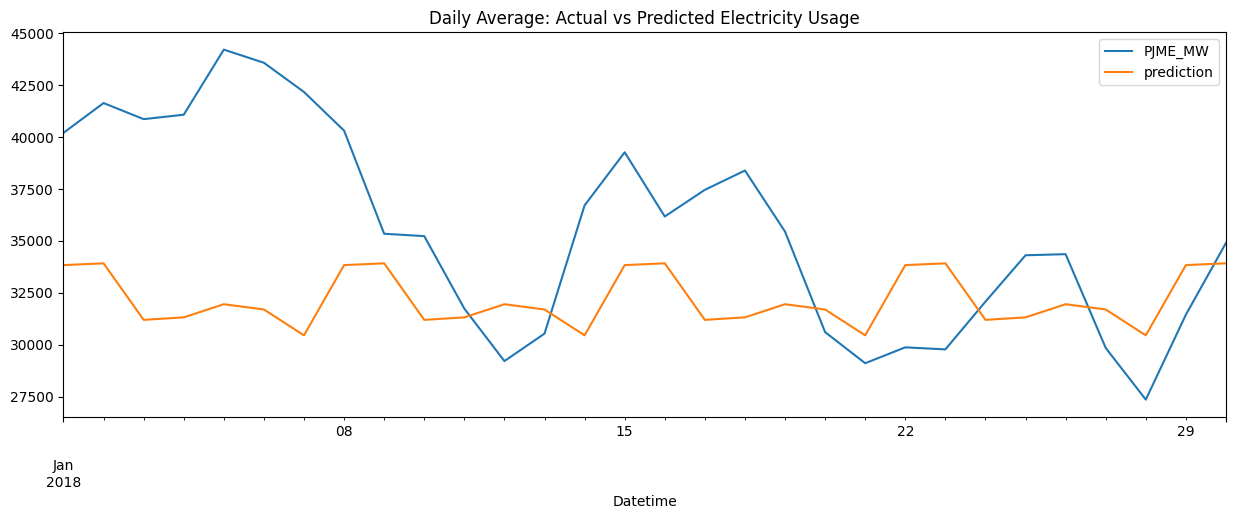

In [37]:
daily_comparison = comparison[['PJME_MW', 'prediction']].resample('D').mean()

daily_comparison.iloc[:30].plot(
    figsize=(15,5),
    title='Daily Average: Actual vs Predicted Electricity Usage'
)


<Axes: title={'center': 'Daily Average Electricity Usage: Actual vs Predicted'}, xlabel='Datetime'>

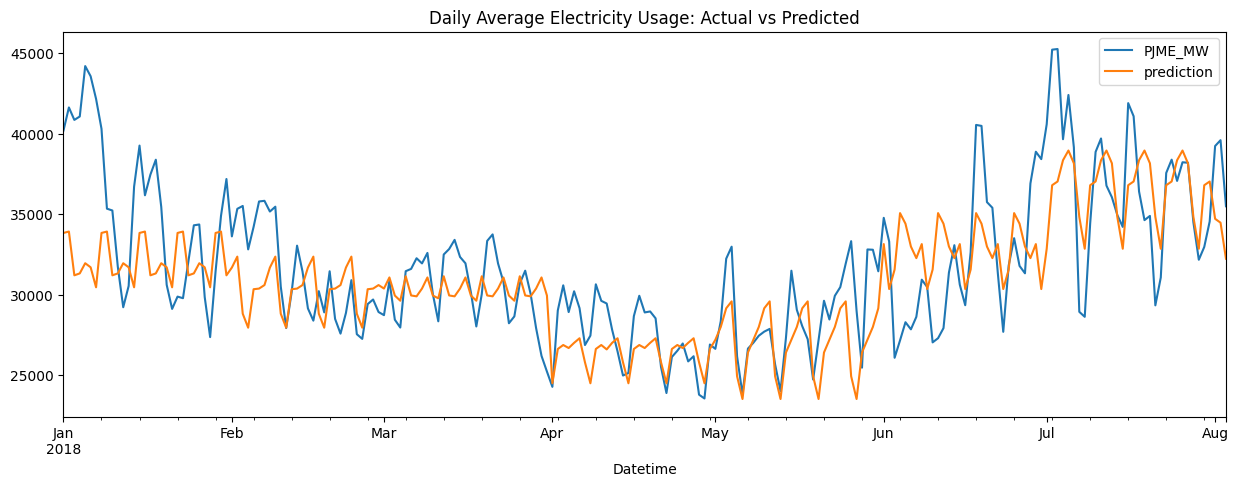

In [38]:
daily = comparison[['PJME_MW', 'prediction']].resample('D').mean()

daily.plot(
    figsize=(15,5),
    title='Daily Average Electricity Usage: Actual vs Predicted'
)


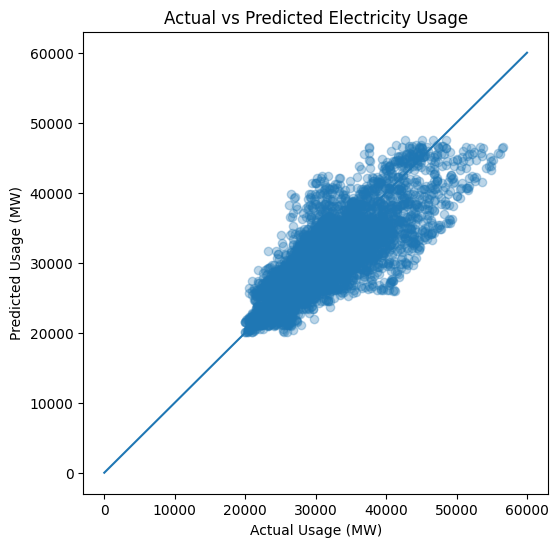

In [39]:
plt.figure(figsize=(6,6))
plt.scatter(comparison['PJME_MW'], comparison['prediction'], alpha=0.3)
plt.plot([0, 60000], [0, 60000])  # perfect prediction line
plt.xlabel('Actual Usage (MW)')
plt.ylabel('Predicted Usage (MW)')
plt.title('Actual vs Predicted Electricity Usage')
plt.show()


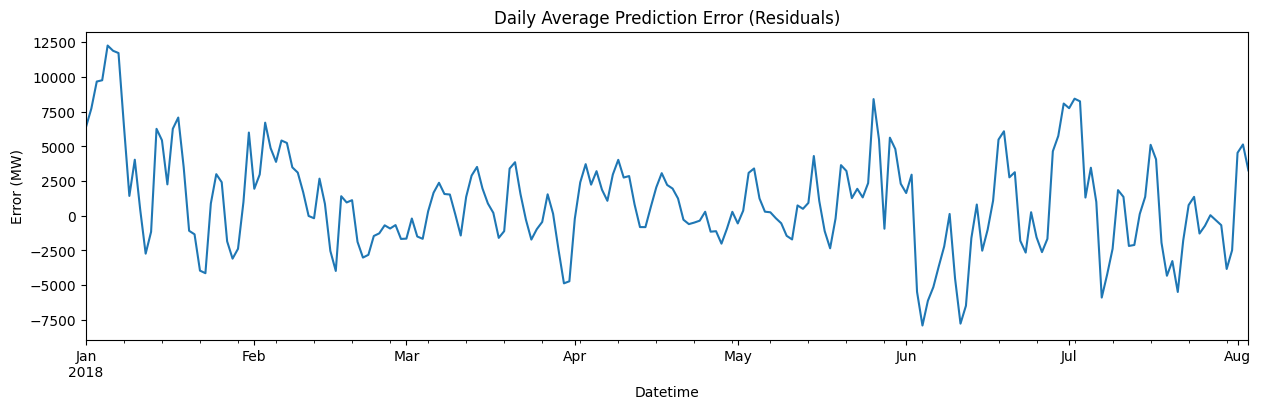

In [40]:
comparison['residual'] = comparison['PJME_MW'] - comparison['prediction']

plt.figure(figsize=(15,4))
comparison['residual'].resample('D').mean().plot()
plt.title('Daily Average Prediction Error (Residuals)')
plt.ylabel('Error (MW)')
plt.show()


<Figure size 1500x500 with 0 Axes>

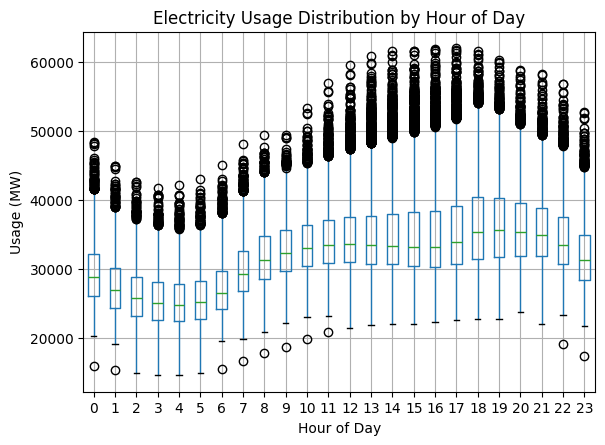

In [41]:
plt.figure(figsize=(15,5))
df.boxplot(column='PJME_MW', by='hour')
plt.title('Electricity Usage Distribution by Hour of Day')
plt.suptitle('')
plt.xlabel('Hour of Day')
plt.ylabel('Usage (MW)')
plt.show()


<Figure size 1000x500 with 0 Axes>

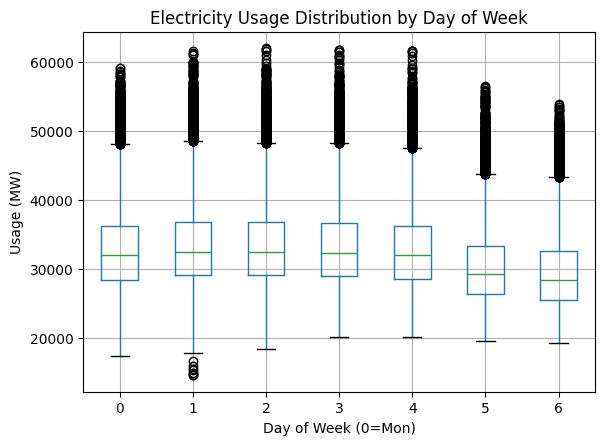

In [42]:
plt.figure(figsize=(10,5))
df.boxplot(column='PJME_MW', by='dayofweek')
plt.title('Electricity Usage Distribution by Day of Week')
plt.suptitle('')
plt.xlabel('Day of Week (0=Mon)')
plt.ylabel('Usage (MW)')
plt.show()


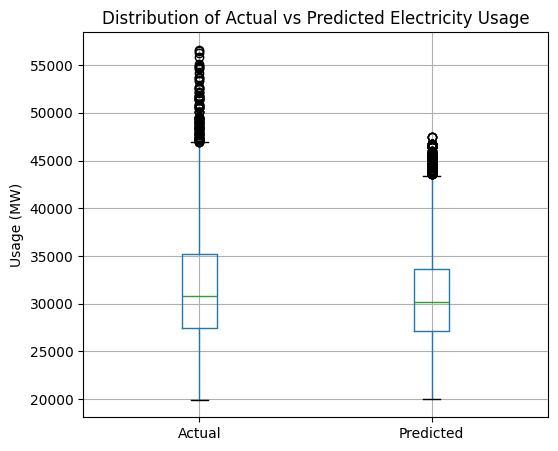

In [43]:
box_data = pd.DataFrame({
    'Actual': comparison['PJME_MW'],
    'Predicted': comparison['prediction']
})

plt.figure(figsize=(6,5))
box_data.boxplot()
plt.title('Distribution of Actual vs Predicted Electricity Usage')
plt.ylabel('Usage (MW)')
plt.show()


In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


In [45]:
lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

In [46]:
lr_preds = lr.predict(X_test)


In [47]:
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_mae


4316.575351205109

In [48]:
results = pd.DataFrame({
    'Model': ['Baseline (Mean)', 'Linear Regression', 'Random Forest'],
    'MAE': [baseline_mae, lr_mae, rf_mae]
})

results


,Model,MAE
0,Baseline (Mean),4963.662948
1,Linear Regression,4316.575351
2,Random Forest,2981.101220


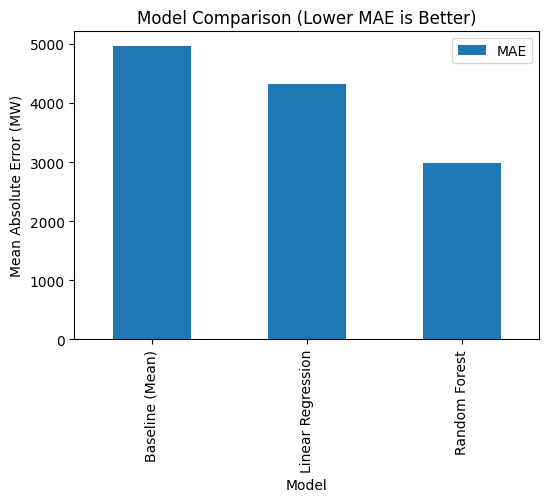

In [49]:
results.set_index('Model').plot(kind='bar', figsize=(6,4))
plt.title('Model Comparison (Lower MAE is Better)')
plt.ylabel('Mean Absolute Error (MW)')
plt.show()


<Axes: title={'center': 'Feature Importance'}>

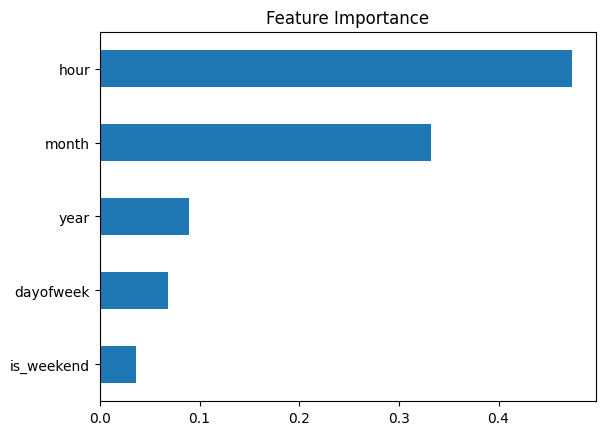

In [50]:
pd.Series(
    rf.feature_importances_,
    index=features
).sort_values().plot(kind='barh', title='Feature Importance')


Hour of day and month were the most influential predictors

“A Linear Regression model was trained as a benchmark and compared against a Random Forest regressor. While Linear Regression captured general demand trends, it struggled with non-linear seasonal patterns. The Random Forest model achieved a lower MAE, demonstrating superior performance in modeling complex electricity usage behavior.”